<a href="https://colab.research.google.com/github/Lettola/Lettola/blob/main/AlphaFold2_automatized_samples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/sokrypton/ColabFold/main/.github/ColabFold_Marv_Logo_Small.png" height="200" align="right" style="height:240px">

##ColabFold v1.5.5.1: AlphaFold2 using MMseqs2 (Modified for Batch Automation)

Easy to use protein structure and complex prediction using [AlphaFold2](https://www.nature.com/articles/s41586-021-03819-2) and [Alphafold2-multimer](https://www.biorxiv.org/content/10.1101/2021.10.04.463034v1). Sequence alignments/templates are generated through [MMseqs2](mmseqs.com) and [HHsearch](https://github.com/soedinglab/hh-suite). For more details, see <a href="#Instructions">bottom</a> of the notebook, checkout the [ColabFold GitHub](https://github.com/sokrypton/ColabFold) and [Nature Protocols](https://www.nature.com/articles/s41596-024-01060-5).

Old versions: [v1.4](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.4.0/AlphaFold2.ipynb), [v1.5.1](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.1/AlphaFold2.ipynb), [v1.5.2](https://colab.research.google.com/github/sokrypton/ColabFold/blob/v1.5.2/AlphaFold2.ipynb), [v1.5.3-patch](https://colab.research.google.com/github/sokrypton/ColabFold/blob/56c72044c7d51a311ca99b953a71e552fdc042e1/AlphaFold2.ipynb)

New in this version: Now supports batch processing of multiple sequences from a .txt file. Modified by Elena Pares-Guillen

# Installations and packages (run once)

In [3]:
%%time

import os
import warnings
from sys import version_info

# Variables de configuración
USE_AMBER = globals().get("use_amber", False)
USE_TEMPLATES = globals().get("use_templates", False)
PYTHON_VERSION = f"{version_info.major}.{version_info.minor}"

# Instalar ColabFold si no está listo
if not os.path.isfile("COLABFOLD_READY"):
    print("Installing ColabFold...")
    os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
    if os.environ.get('TPU_NAME', False):
        os.system("pip uninstall -y jax jaxlib")
        os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
    os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
    os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
    os.system("touch COLABFOLD_READY")

# Instalar Conda si se necesita Amber o Templates
if (USE_AMBER or USE_TEMPLATES) and not os.path.isfile("CONDA_READY"):
    print("Installing Conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

# Instalar Amber y/o HHSuite según necesidad
if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("Installing HHSuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")

if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("Installing Amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

UsageError: Line magic function `%%time` not found.


In [7]:
if save_to_google_drive:
  from pydrive2.drive import GoogleDrive
  from pydrive2.auth import GoogleAuth
  from google.colab import auth
  from oauth2client.client import GoogleCredentials
  auth.authenticate_user()
  gauth = GoogleAuth()
  gauth.credentials = GoogleCredentials.get_application_default()
  drive = GoogleDrive(gauth)
  print("You are logged into Google Drive and are good to go!")

In [8]:
import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2

import os
import numpy as np
try:
  K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
except:
  K80_chk = "0"
  pass
if "1" in K80_chk:
  print("WARNING: found GPU Tesla K80: limited to total length < 1000")
  if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
    del os.environ["TF_FORCE_UNIFIED_MEMORY"]
  if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
    del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

from colabfold.colabfold import plot_protein
from pathlib import Path
import matplotlib.pyplot as plt

In [9]:
import py3Dmol
import glob
import matplotlib.pyplot as plt
from colabfold.colabfold import plot_plddt_legend
from colabfold.colabfold import pymol_color_list, alphabet_list
rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
show_sidechains = False #@param {type:"boolean"}
show_mainchains = False #@param {type:"boolean"}

In [10]:
from IPython.display import display, HTML
import base64
from html import escape

# Code (run all)

jobname fragment_0_1135e_0
sequence LALLLNAAGRGLFPAAGVTFRPDCRAEDLEASLEPADFNIRPAAVDDIDTLHMLETVCWPKELQTPTKTLASRVAIDPNGQLVLTLDGSPCGVIYSQRINSVEALTSSDMDKVDSLRDPSGSILHFLAINILPSVQDRGLGDALLEFILHYAALAPGIKSAAAVTLCRDFTGRTLSDLNEYLRRKTPLGTVADPVLRFHELHGGRIQHPVPNYRARDTRNLGAGVLVTYDLNKRRRSHAPQPRQKIARTDIANRVNSAIRSALGSSSDQFEKDTPLISMGLDSAAILGLADCLQAECGSTLTAAQLFKHNTAEKIIAFLHNELPSSGLSKPTLLPAQTSCPADGGSDQSVAIIGVSLRMPGGIETPQALWELLDLGGTVITPVPSDRWSWPDGFRPQGAAYGGFLQDPARFDAAFFRISPHEAEAMDPQQRILLELAWHGLEDAGLSATKLAGSSTGVFVGASGSDYQRAMDAAGVPVQPHHSTGAALSVIANRLSYALD
length 500


2025-07-21 14:02:39,959 WARNING: no GPU detected, will be using CPU
2025-07-21 14:02:45,101 Found 5 citations for tools or databases
2025-07-21 14:02:45,102 Query 1/1: fragment_0_1135e_0 (length 500)


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:02 remaining: 00:00]


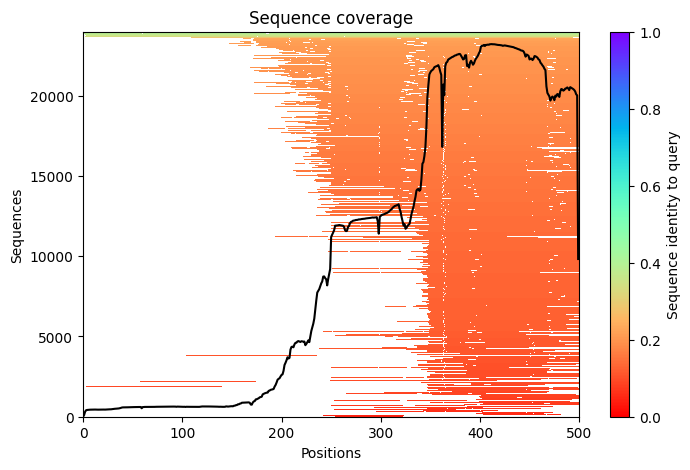

2025-07-21 14:02:57,670 Setting max_seq=512, max_extra_seq=5120


In [ ]:
## Input protein sequence(s)
def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]


# EDIT THIS CODE WITH YOUR .TXT FILE WITH THE SEQUENCES

with open('/content/fragmented_sequence_lab4_noname.txt') as f:
    secuencias = [line.strip() for line in f if line.strip()]

for i, seq in enumerate(secuencias):
    query_sequence = seq
    #@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
    jobname = f"fragment_{i}" #@param {type:"string"}
    # number of models to use
    num_relax = 0 #@param [0, 1, 5] {type:"raw"}
    #@markdown - specify how many of the top ranked structures to relax using amber
    template_mode = "none" #@param ["none", "pdb100","custom"]
    #@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

    use_amber = num_relax > 0

    # remove whitespaces
    query_sequence = "".join(query_sequence.split())

    basejobname = "".join(jobname.split())
    basejobname = re.sub(r'\W+', '', basejobname)
    jobname = add_hash(basejobname, query_sequence)

    # check if directory with jobname exists
    def check(folder):
      if os.path.exists(folder):
        return False
      else:
        return True
    if not check(jobname):
      n = 0
      while not check(f"{jobname}_{n}"): n += 1
      jobname = f"{jobname}_{n}"

    # make directory to save results
    os.makedirs(jobname, exist_ok=True)

    # save queries
    queries_path = os.path.join(jobname, f"{jobname}.csv")
    with open(queries_path, "w") as text_file:
      text_file.write(f"id,sequence\n{jobname},{query_sequence}")

    if template_mode == "pdb100":
      use_templates = True
      custom_template_path = None
    elif template_mode == "custom":
      custom_template_path = os.path.join(jobname,f"template")
      os.makedirs(custom_template_path, exist_ok=True)
      uploaded = files.upload()
      use_templates = True
      for fn in uploaded.keys():
        os.rename(fn,os.path.join(custom_template_path,fn))
    else:
      custom_template_path = None
      use_templates = False

    print("jobname",jobname)
    print("sequence",query_sequence)
    print("length",len(query_sequence.replace(":","")))

## MSA options (custom MSA upload, single sequence, pairing mode)

    #@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
    msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
    pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
    #@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

    # decide which a3m to use
    if "mmseqs2" in msa_mode:
      a3m_file = os.path.join(jobname,f"{jobname}.a3m")

    elif msa_mode == "custom":
      a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
      if not os.path.isfile(a3m_file):
        custom_msa_dict = files.upload()
        custom_msa = list(custom_msa_dict.keys())[0]
        header = 0
        import fileinput
        for line in fileinput.FileInput(custom_msa,inplace=1):
          if line.startswith(">"):
            header = header + 1
          if not line.rstrip():
            continue
          if line.startswith(">") == False and header == 1:
            query_sequence = line.rstrip()
          print(line, end='')

        os.rename(custom_msa, a3m_file)
        queries_path=a3m_file
        print(f"moving {custom_msa} to {a3m_file}")

    else:
      a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
      with open(a3m_file, "w") as text_file:
        text_file.write(">1\n%s" % query_sequence)

## Advanced settings

    #@markdown ### Advanced settings
    model_type = "auto" #@param ["auto", "alphafold2_ptm", "alphafold2_multimer_v1", "alphafold2_multimer_v2", "alphafold2_multimer_v3", "deepfold_v1", "alphafold2"]
    #@markdown - if `auto` selected, will use `alphafold2_ptm` for monomer prediction and `alphafold2_multimer_v3` for complex prediction.
    #@markdown Any of the mode_types can be used (regardless if input is monomer or complex).
    num_recycles = "3" #@param ["auto", "0", "1", "3", "6", "12", "24", "48"]
    #@markdown - if `auto` selected, will use `num_recycles=20` if `model_type=alphafold2_multimer_v3`, else `num_recycles=3` .
    recycle_early_stop_tolerance = "auto" #@param ["auto", "0.0", "0.5", "1.0"]
    #@markdown - if `auto` selected, will use `tol=0.5` if `model_type=alphafold2_multimer_v3` else `tol=0.0`.
    relax_max_iterations = 200 #@param [0, 200, 2000] {type:"raw"}
    #@markdown - max amber relax iterations, `0` = unlimited (AlphaFold2 default, can take very long)
    pairing_strategy = "greedy" #@param ["greedy", "complete"] {type:"string"}
    #@markdown - `greedy` = pair any taxonomically matching subsets, `complete` = all sequences have to match in one line.
    calc_extra_ptm = False #@param {type:"boolean"}
    #@markdown - return pairwise chain iptm/actifptm

    #@markdown #### Sample settings
    #@markdown -  enable dropouts and increase number of seeds to sample predictions from uncertainty of the model.
    #@markdown -  decrease `max_msa` to increase uncertainity
    max_msa = "auto" #@param ["auto", "512:1024", "256:512", "64:128", "32:64", "16:32"]
    num_seeds = 1 #@param [1,2,4,8,16] {type:"raw"}
    use_dropout = False #@param {type:"boolean"}

    num_recycles = None if num_recycles == "auto" else int(num_recycles)
    recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
    if max_msa == "auto": max_msa = None

    #@markdown #### Save settings
    save_all = False #@param {type:"boolean"}
    save_recycles = False #@param {type:"boolean"}
    save_to_google_drive = False #@param {type:"boolean"}
    #@markdown -  if the save_to_google_drive option was selected, the result zip will be uploaded to your Google Drive
    dpi = 200 #@param {type:"integer"}
    #@markdown - set dpi for image resolution

## Run Prediction
    display_images = True #@param {type:"boolean"}

    # For some reason we need that to get pdbfixer to import
    if use_amber and f"/usr/local/lib/python{python_version}/site-packages/" not in sys.path:
        sys.path.insert(0, f"/usr/local/lib/python{python_version}/site-packages/")

    def input_features_callback(input_features):
      if display_images:
        plot_msa_v2(input_features)
        plt.show()
        plt.close()

    def prediction_callback(protein_obj, length,
                            prediction_result, input_features, mode):
      model_name, relaxed = mode
      if not relaxed:
        if display_images:
          fig = plot_protein(protein_obj, Ls=length, dpi=150)
          plt.show()
          plt.close()

    result_dir = jobname
    log_filename = os.path.join(jobname,"log.txt")
    setup_logging(Path(log_filename))

    queries, is_complex = get_queries(queries_path)
    model_type = set_model_type(is_complex, model_type)

    if "multimer" in model_type and max_msa is not None:
      use_cluster_profile = False
    else:
      use_cluster_profile = True

    download_alphafold_params(model_type, Path("."))
    results = run(
        queries=queries,
        result_dir=result_dir,
        use_templates=use_templates,
        custom_template_path=custom_template_path,
        num_relax=num_relax,
        msa_mode=msa_mode,
        model_type=model_type,
        num_models=5,
        num_recycles=num_recycles,
        relax_max_iterations=relax_max_iterations,
        recycle_early_stop_tolerance=recycle_early_stop_tolerance,
        num_seeds=num_seeds,
        use_dropout=use_dropout,
        model_order=[1,2,3,4,5],
        is_complex=is_complex,
        data_dir=Path("."),
        keep_existing_results=False,
        rank_by="auto",
        pair_mode=pair_mode,
        pairing_strategy=pairing_strategy,
        stop_at_score=float(100),
        prediction_callback=prediction_callback,
        dpi=dpi,
        zip_results=False,
        save_all=save_all,
        max_msa=max_msa,
        use_cluster_profile=use_cluster_profile,
        input_features_callback=input_features_callback,
        save_recycles=save_recycles,
        user_agent="colabfold/google-colab-main",
        calc_extra_ptm=calc_extra_ptm,
    )
    results_zip = f"{jobname}.result.zip"
    os.system(f"zip -r {results_zip} {jobname}")

## Display 3D structure
    rank_num = 1 #@param ["1", "2", "3", "4", "5"] {type:"raw"}
    color = "lDDT" #@param ["chain", "lDDT", "rainbow"]
    show_sidechains = False #@param {type:"boolean"}
    show_mainchains = False #@param {type:"boolean"}

    tag = results["rank"][0][rank_num - 1]
    jobname_prefix = ".custom" if msa_mode == "custom" else ""
    pdb_filename = f"{jobname}/{jobname}{jobname_prefix}_unrelaxed_{tag}.pdb"
    pdb_file = glob.glob(pdb_filename)

    def show_pdb(rank_num=1, show_sidechains=False, show_mainchains=False, color="lDDT"):
      model_name = f"rank_{rank_num}"
      view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js',)
      view.addModel(open(pdb_file[0],'r').read(),'pdb')

      if color == "lDDT":
        view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':50,'max':90}}})
      elif color == "rainbow":
        view.setStyle({'cartoon': {'color':'spectrum'}})
      elif color == "chain":
        chains = len(queries[0][1]) + 1 if is_complex else 1
        for n,chain,color in zip(range(chains),alphabet_list,pymol_color_list):
          view.setStyle({'chain':chain},{'cartoon': {'color':color}})

      if show_sidechains:
        BB = ['C','O','N']
        view.addStyle({'and':[{'resn':["GLY","PRO"],'invert':True},{'atom':BB,'invert':True}]},
                            {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
        view.addStyle({'and':[{'resn':"GLY"},{'atom':'CA'}]},
                            {'sphere':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
        view.addStyle({'and':[{'resn':"PRO"},{'atom':['C','O'],'invert':True}]},
                            {'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})
      if show_mainchains:
        BB = ['C','O','N','CA']
        view.addStyle({'atom':BB},{'stick':{'colorscheme':f"WhiteCarbon",'radius':0.3}})

      view.zoomTo()
      return view

    show_pdb(rank_num, show_sidechains, show_mainchains, color).show()
    if color == "lDDT":
      plot_plddt_legend().show()

## Plot

    # see: https://stackoverflow.com/a/53688522
    def image_to_data_url(filename):
      ext = filename.split('.')[-1]
      prefix = f'data:image/{ext};base64,'
      with open(filename, 'rb') as f:
        img = f.read()
      return prefix + base64.b64encode(img).decode('utf-8')

    pae = ""
    pae_file = os.path.join(jobname,f"{jobname}{jobname_prefix}_pae.png")
    if os.path.isfile(pae_file):
        pae = image_to_data_url(pae_file)
    cov = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_coverage.png"))
    plddt = image_to_data_url(os.path.join(jobname,f"{jobname}{jobname_prefix}_plddt.png"))
    display(HTML(f"""
    <style>
      img {{
        float:left;
      }}
      .full {{
        max-width:100%;
      }}
      .half {{
        max-width:50%;
      }}
      @media (max-width:640px) {{
        .half {{
          max-width:100%;
        }}
      }}
    </style>
    <div style="max-width:90%; padding:2em;">
      <h1>Plots for {escape(jobname)}</h1>
      { '<!--' if pae == '' else '' }<img src="{pae}" class="full" />{ '-->' if pae == '' else '' }
      <img src="{cov}" class="half" />
      <img src="{plddt}" class="half" />
    </div>
    """))

## Package and download results


    if msa_mode == "custom":
      print("Don't forget to cite your custom MSA generation method.")

    files.download(f"{jobname}.result.zip")

    if save_to_google_drive == True and drive:
      uploaded = drive.CreateFile({'title': f"{jobname}.result.zip"})
      uploaded.SetContentFile(f"{jobname}.result.zip")
      uploaded.Upload()
      print(f"Uploaded {jobname}.result.zip to Google Drive with ID {uploaded.get('id')}")